In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("avocado.csv")

print (data.head())

   Unnamed: 0        Date  AveragePrice  Total Volume     4046       4225  \
0           0  2015-12-27          1.33      64236.62  1036.74   54454.85   
1           1  2015-12-20          1.35      54876.98   674.28   44638.81   
2           2  2015-12-13          0.93     118220.22   794.70  109149.67   
3           3  2015-12-06          1.08      78992.15  1132.00   71976.41   
4           4  2015-11-29          1.28      51039.60   941.48   43838.39   

     4770  Total Bags  Small Bags  Large Bags  XLarge Bags          type  \
0   48.16     8696.87     8603.62       93.25          0.0  conventional   
1   58.33     9505.56     9408.07       97.49          0.0  conventional   
2  130.50     8145.35     8042.21      103.14          0.0  conventional   
3   72.58     5811.16     5677.40      133.76          0.0  conventional   
4   75.78     6183.95     5986.26      197.69          0.0  conventional   

   year  region  
0  2015  Albany  
1  2015  Albany  
2  2015  Albany  
3  2015 

In [10]:
%matplotlib widget 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.preprocessing import StandardScaler

sample = data.sample (n=1000, random_state=42)

scaler = StandardScaler()

ap = sample["AveragePrice"].values
tv = sample["Total Volume"].values.reshape(-1, 1)
sample["type_encoded"] = sample["type"].map({"conventional": 0, "organic": 1})
type_x = sample["type_encoded"].values.reshape(-1, 1)

sample["Date"] = pd.to_datetime(sample["Date"])
day = (sample["Date"] - sample["Date"].min()).dt.days.values.reshape(-1, 1)

X = np.column_stack((day, tv, type_x))
X_scaled = scaler.fit_transform(X)
y = sample["AveragePrice"].values


kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=1, noise_level_bounds=(1e-10, 1e+1))

gaussian_process = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=2, alpha=0.0, normalize_y=True)
gaussian_process.fit(X_scaled, y)

print(f"Optimized kernel: {gaussian_process.kernel_}")



Optimized kernel: 0.739**2 * RBF(length_scale=0.373) + WhiteKernel(noise_level=0.465)


In [11]:
print (X_scaled.shape)
print (y.shape)

(1000, 3)
(1000,)


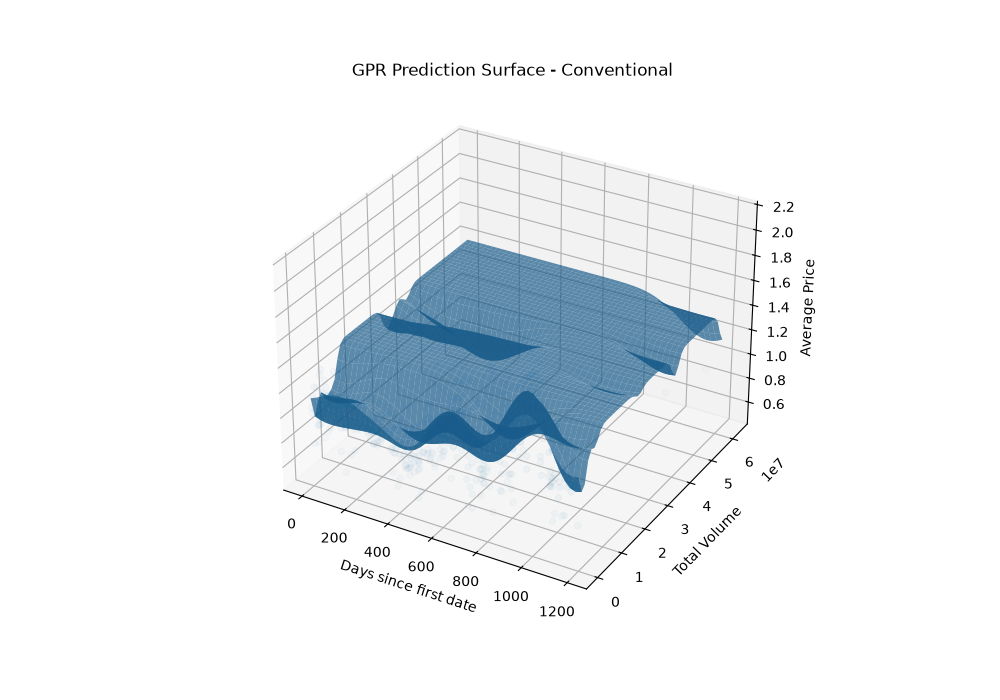

In [12]:
# Keep type constant
fixed_type = 0   # 0 = conventional, 1 = organic

# Create grid of input values
date_grid = np.linspace(
    day.min(),
    day.max() + 20,
    50
)

volume_grid = np.linspace(
    tv.min(),
    tv.max(),
    50
)

# Turn the two 1D grids into a 2D grid
day_mesh, volume_mesh = np.meshgrid(
    date_grid,
    volume_grid
)

# Keep type constant across the whole surface
type_mesh = np.full(
    day_mesh.shape,
    fixed_type
)

# Put every point on the grid into the format the GPR expects
X_grid = np.column_stack((
    day_mesh.ravel(),
    volume_mesh.ravel(),
    type_mesh.ravel()
))

# Scale using the SAME scaler used to train the GPR
X_grid_scaled = scaler.transform(X_grid)

# Predict Average Price
predicted_price = gaussian_process.predict(X_grid_scaled)

# Put predictions back into the 2D grid
predicted_price = predicted_price.reshape(day_mesh.shape)

# -------------------------
# Plot
# -------------------------

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

# GPR prediction surface
ax.plot_surface(
    day_mesh,
    volume_mesh,
    predicted_price,
    alpha=0.7
)

# Add the actual data points for the chosen type
sample_type = sample[sample["type_encoded"] == fixed_type]

sample_days = (
    sample_type["Date"] - sample["Date"].min()
).dt.days

ax.scatter(
    sample_days,
    sample_type["Total Volume"],
    sample_type["AveragePrice"],
    alpha=0.2
)

ax.set_xlabel("Days since first date")
ax.set_ylabel("Total Volume")
ax.set_zlabel("Average Price")

if fixed_type == 0:
    ax.set_title("GPR Prediction Surface - Conventional")
else:
    ax.set_title("GPR Prediction Surface - Organic")

plt.show()

In [13]:
future_day = day.max() + 20
future_volume = 100000
future_type = 0

X_future = np.array([
    [future_day, future_volume, future_type]
])

X_future_scaled = scaler.transform(X_future)

prediction, std = gaussian_process.predict(
    X_future_scaled,
    return_std=True
)

print("Predicted Average Price:", prediction[0])
print("Standard deviation:", std[0])

Predicted Average Price: 1.1413498139957483
Standard deviation: 0.2950882623057756


In [14]:
print(day.max())

1176
